✅ Configuration loaded
✅ Helper functions ready
📂 Please upload your Excel file...


Saving final_hybrid_ipo_dataset.xlsx to final_hybrid_ipo_dataset (1).xlsx
✅ Loading: final_hybrid_ipo_dataset (1).xlsx
✅ Dataset: 389 rows × 31 columns

✅ Split complete:
   Training (listed)   : 377 rows
   Prediction (ongoing): 12 rows

   Ongoing IPOs to predict:
   → Nfp Sampoorna Foods Ltd. Ipo
   → Teamtech Formwork Solutions Ltd. Ipo
   → Vegorama Punjabi Angithi Ltd. Ipo
   → Harikanta Overseas Ltd. Ipo
   → Q-Line Biotech Ltd. Ipo
   → Autofurnish Ltd. Ipo
   → Bio Medica Laboratories Ltd. Ipo
   → M R Maniveni Foods Ltd. Ipo
   → Yaashvi Jewellers Ltd. Ipo
   → Smr Jewels Ltd. Ipo
   → Rajnandini Fashion India Ltd. Ipo
   → Merritronix Ltd. Ipo

  PART 1: Training LSTM on PAT Sequence...
✅ LSTM done — 135 epochs


✅ lstm_pat_score added to all rows

  PART 2: Training XGBoost...
✅ 28 features: ['year', 'issue_price', 'issue_amount', 'pat_current_year__cr', 'roe_', 'roce_', 'debtequity', 'pat_margin_', 'price_to_book_value', 'eps_pre_ipo_', 'eps_post_ipo_', 'pe_pre_ipo_x', 'pe_post_ipo_x', 'promoter_holding_pre_ipo_', 'promoter_holding_post_ipo_', 'industry_pe', 'gmp_', 'retail_demand_x', 'nii_demand_x', 'gmp_percent', 'qib_vs_retail', 'pat_yoy_growth', 'pat_2y_growth', 'log_issue_amount', 'log_pat_current_year__cr', 'log_pat_previous_year__cr', 'log_pat_2nd_previous_year__cr', 'lstm_pat_score']
✅ XGBoost trained!

  HYBRID MODEL PERFORMANCE — 76 validation IPOs
  MAE  : 12.83%
  RMSE : 19.14%
  R²   : 0.3924  (39.2% variance explained)
  Gap  : -0.0009  (✅ Low)

════════════════════════════════════════════════════════════════════════
  LSTM + XGBoost HYBRID — ONGOING IPO PREDICTIONS
════════════════════════════════════════════════════════════════════════

  ╔═════════════════════════════════════

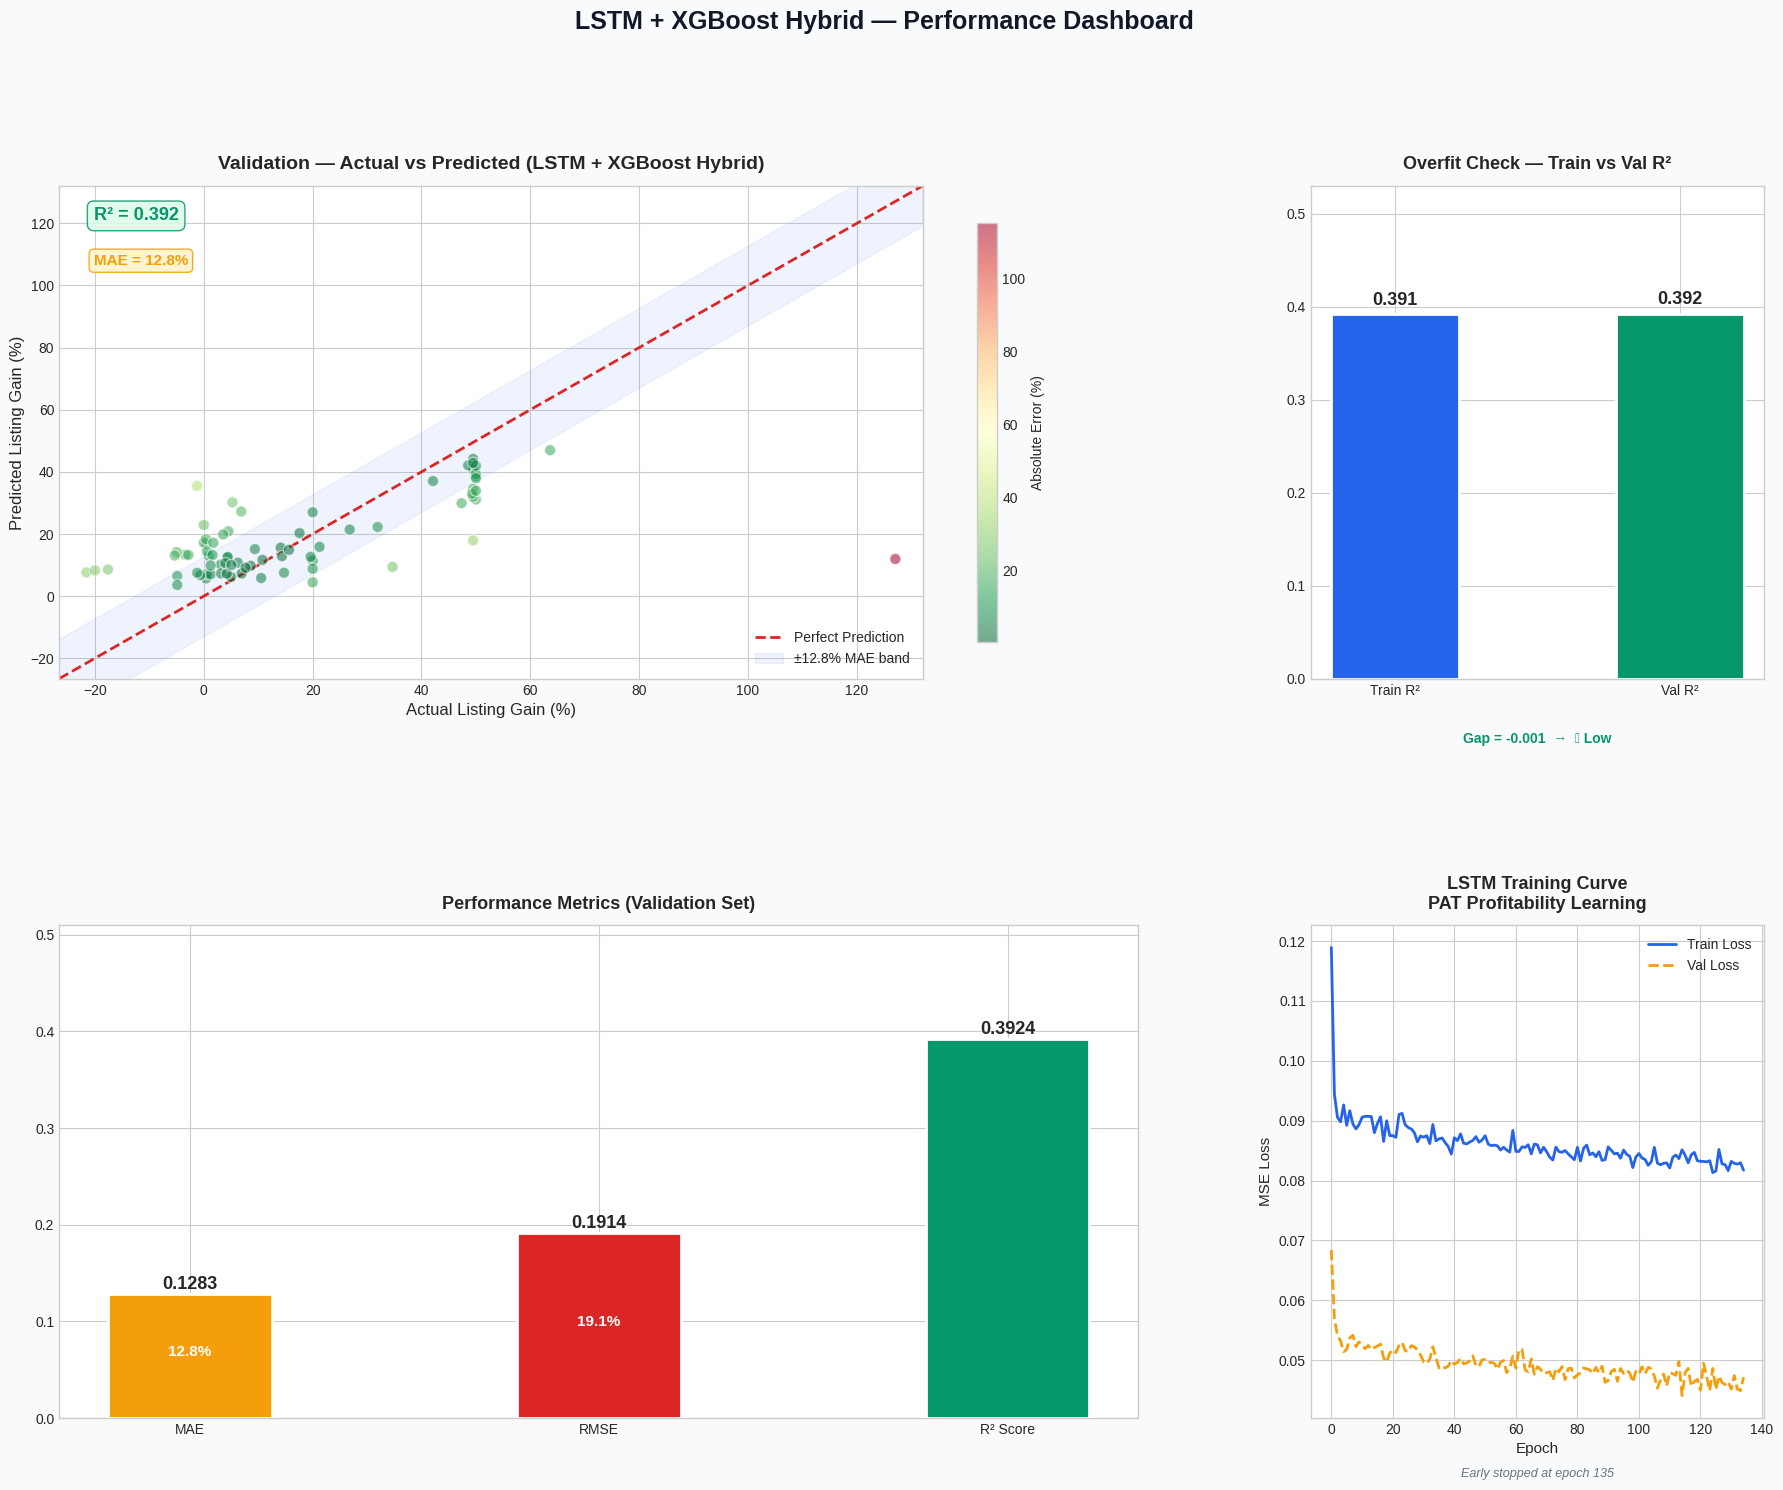

✅ Figure 1 saved


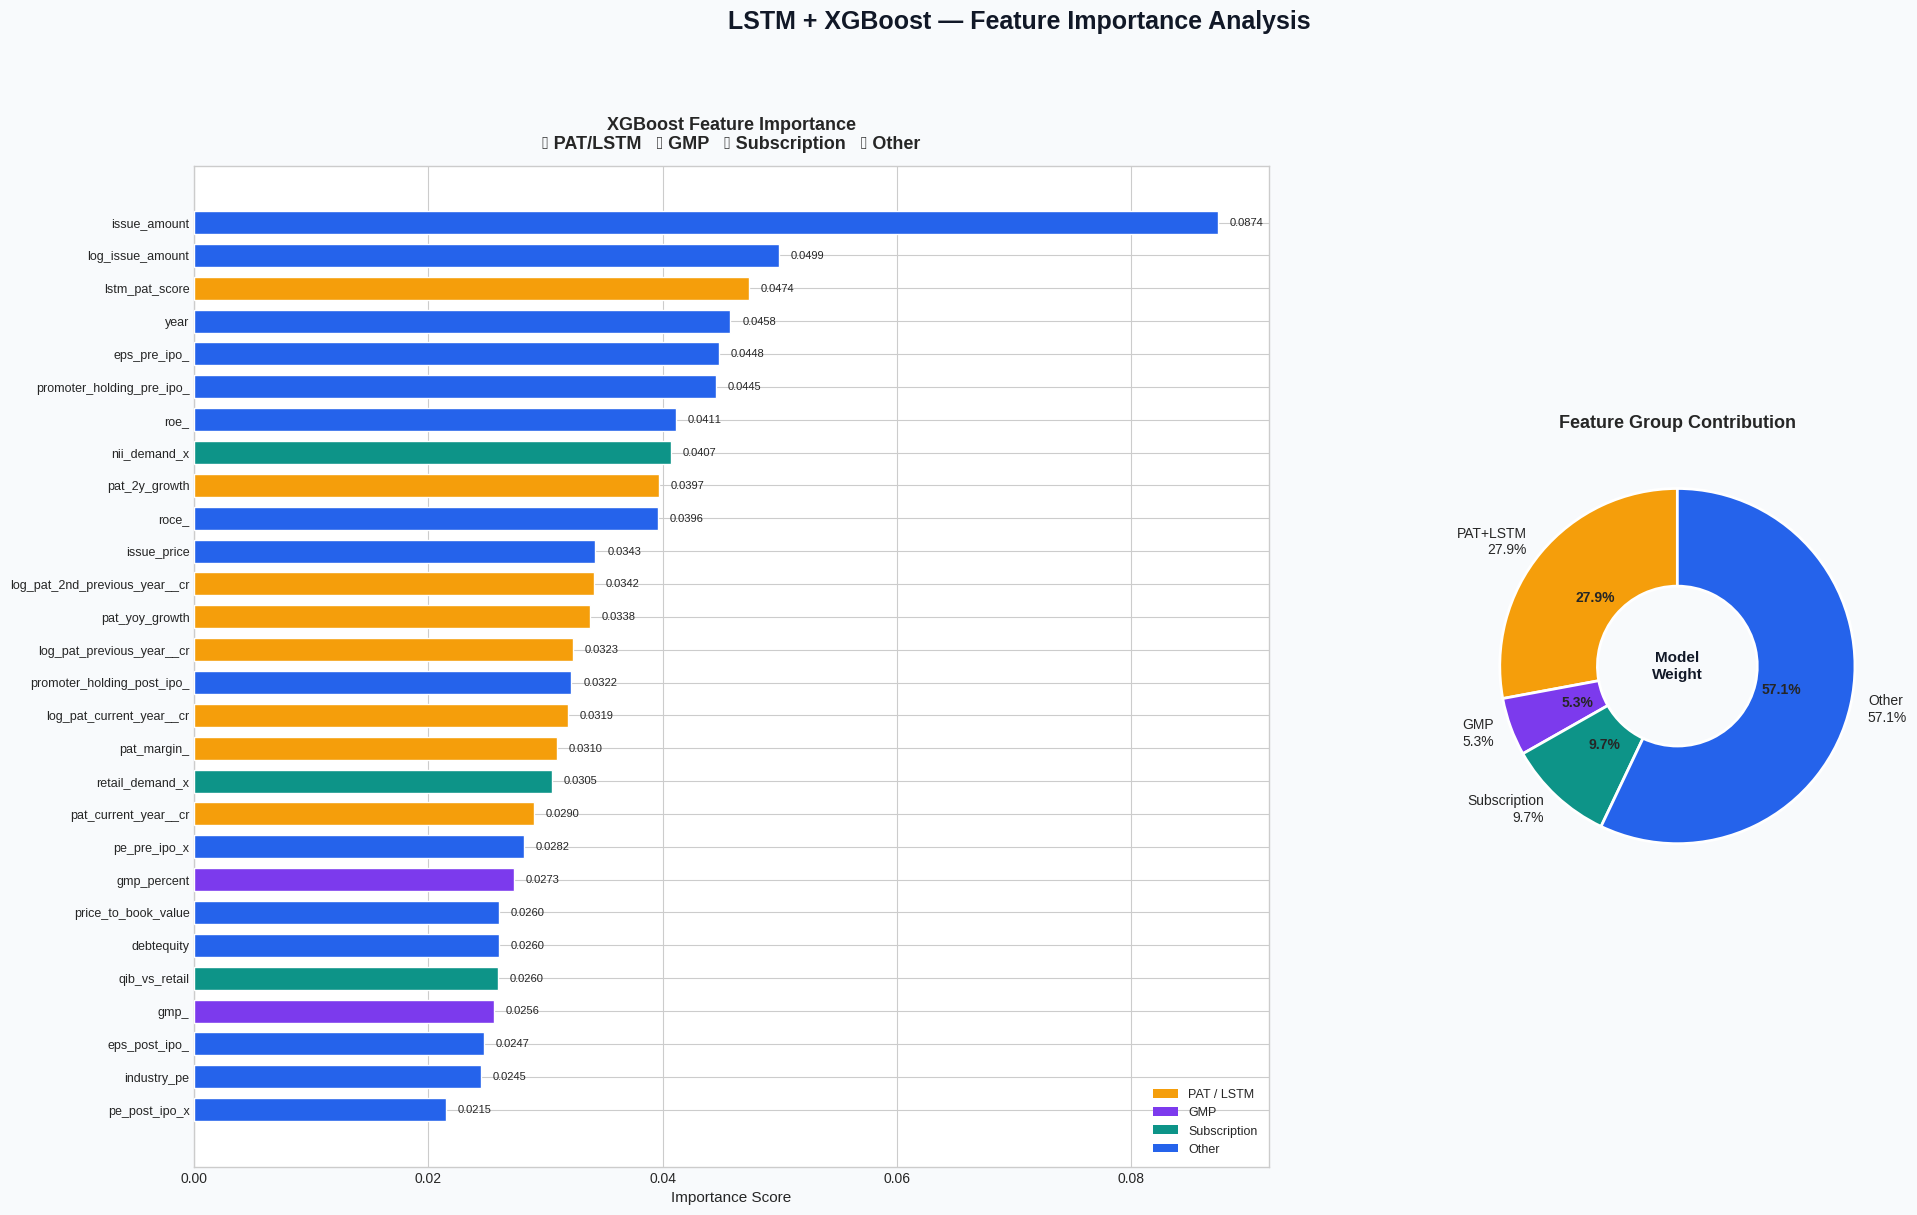

✅ Figure 2 saved


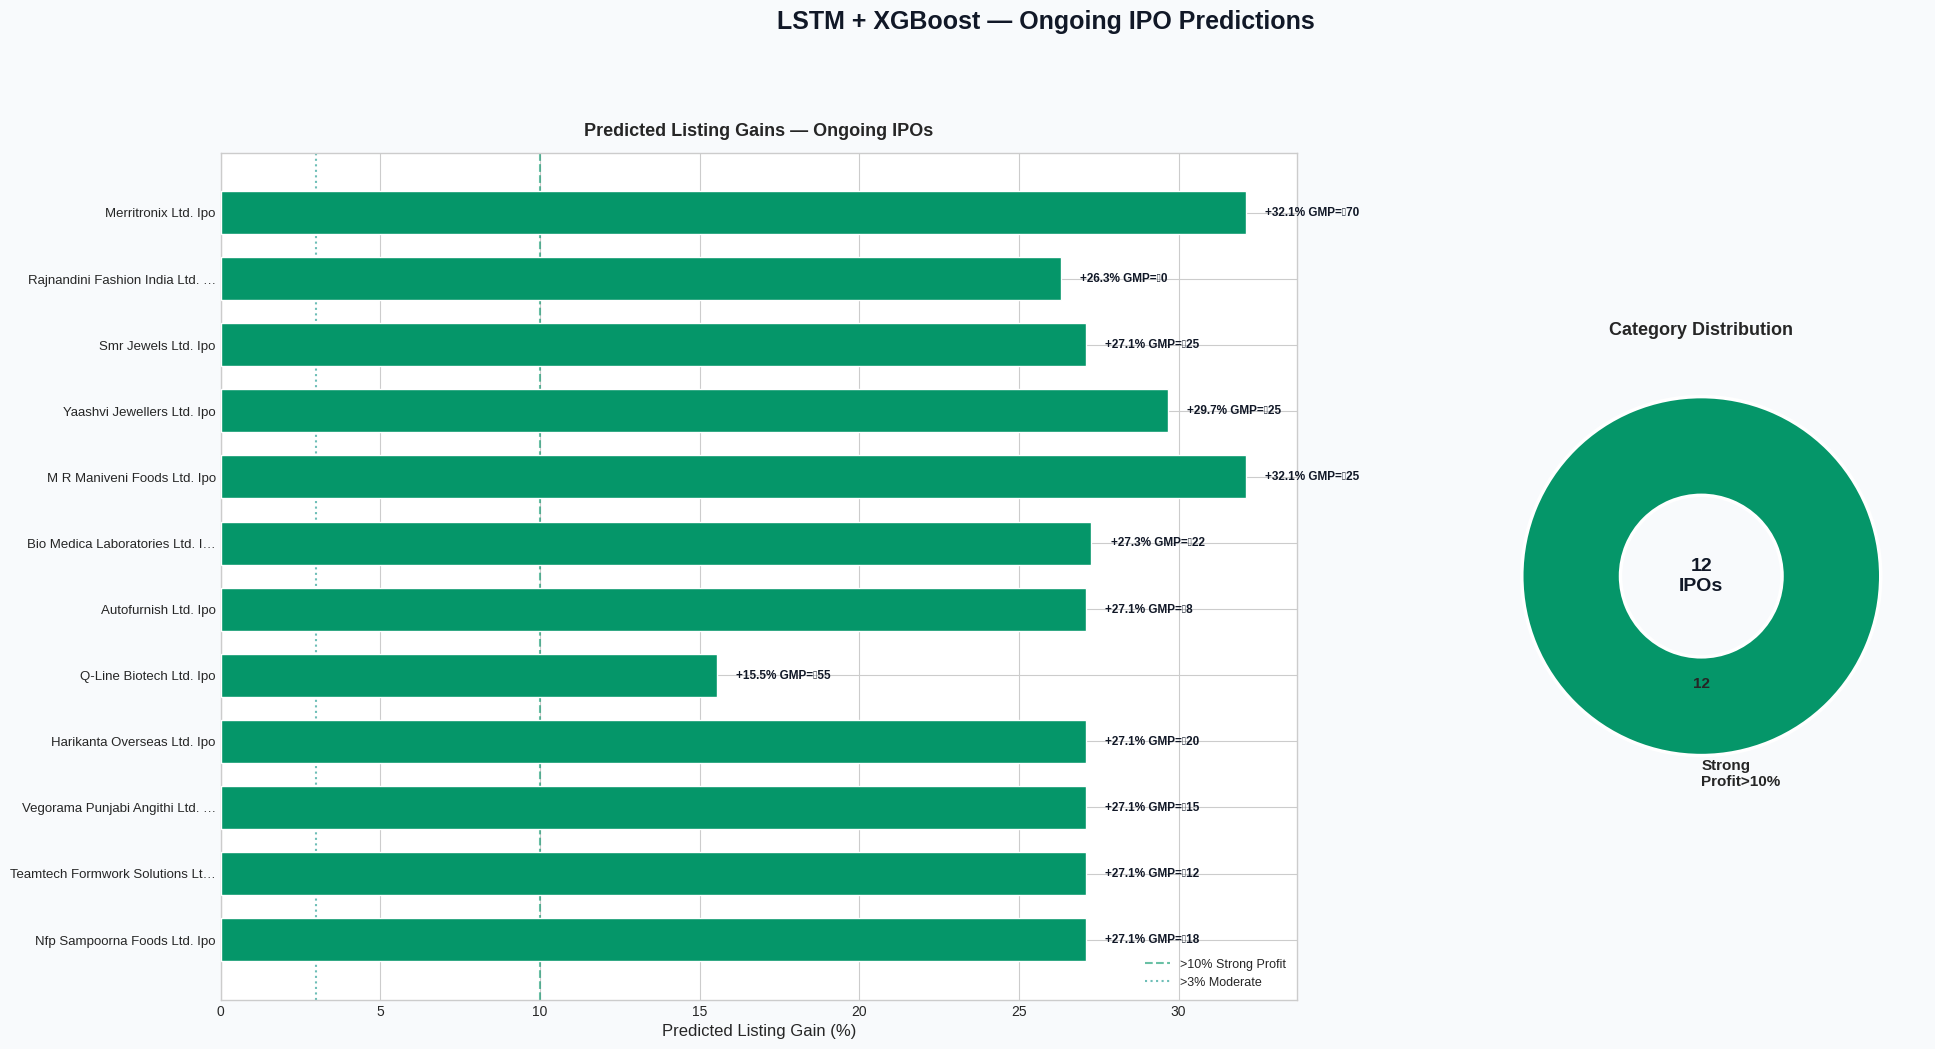

✅ Figure 3 saved


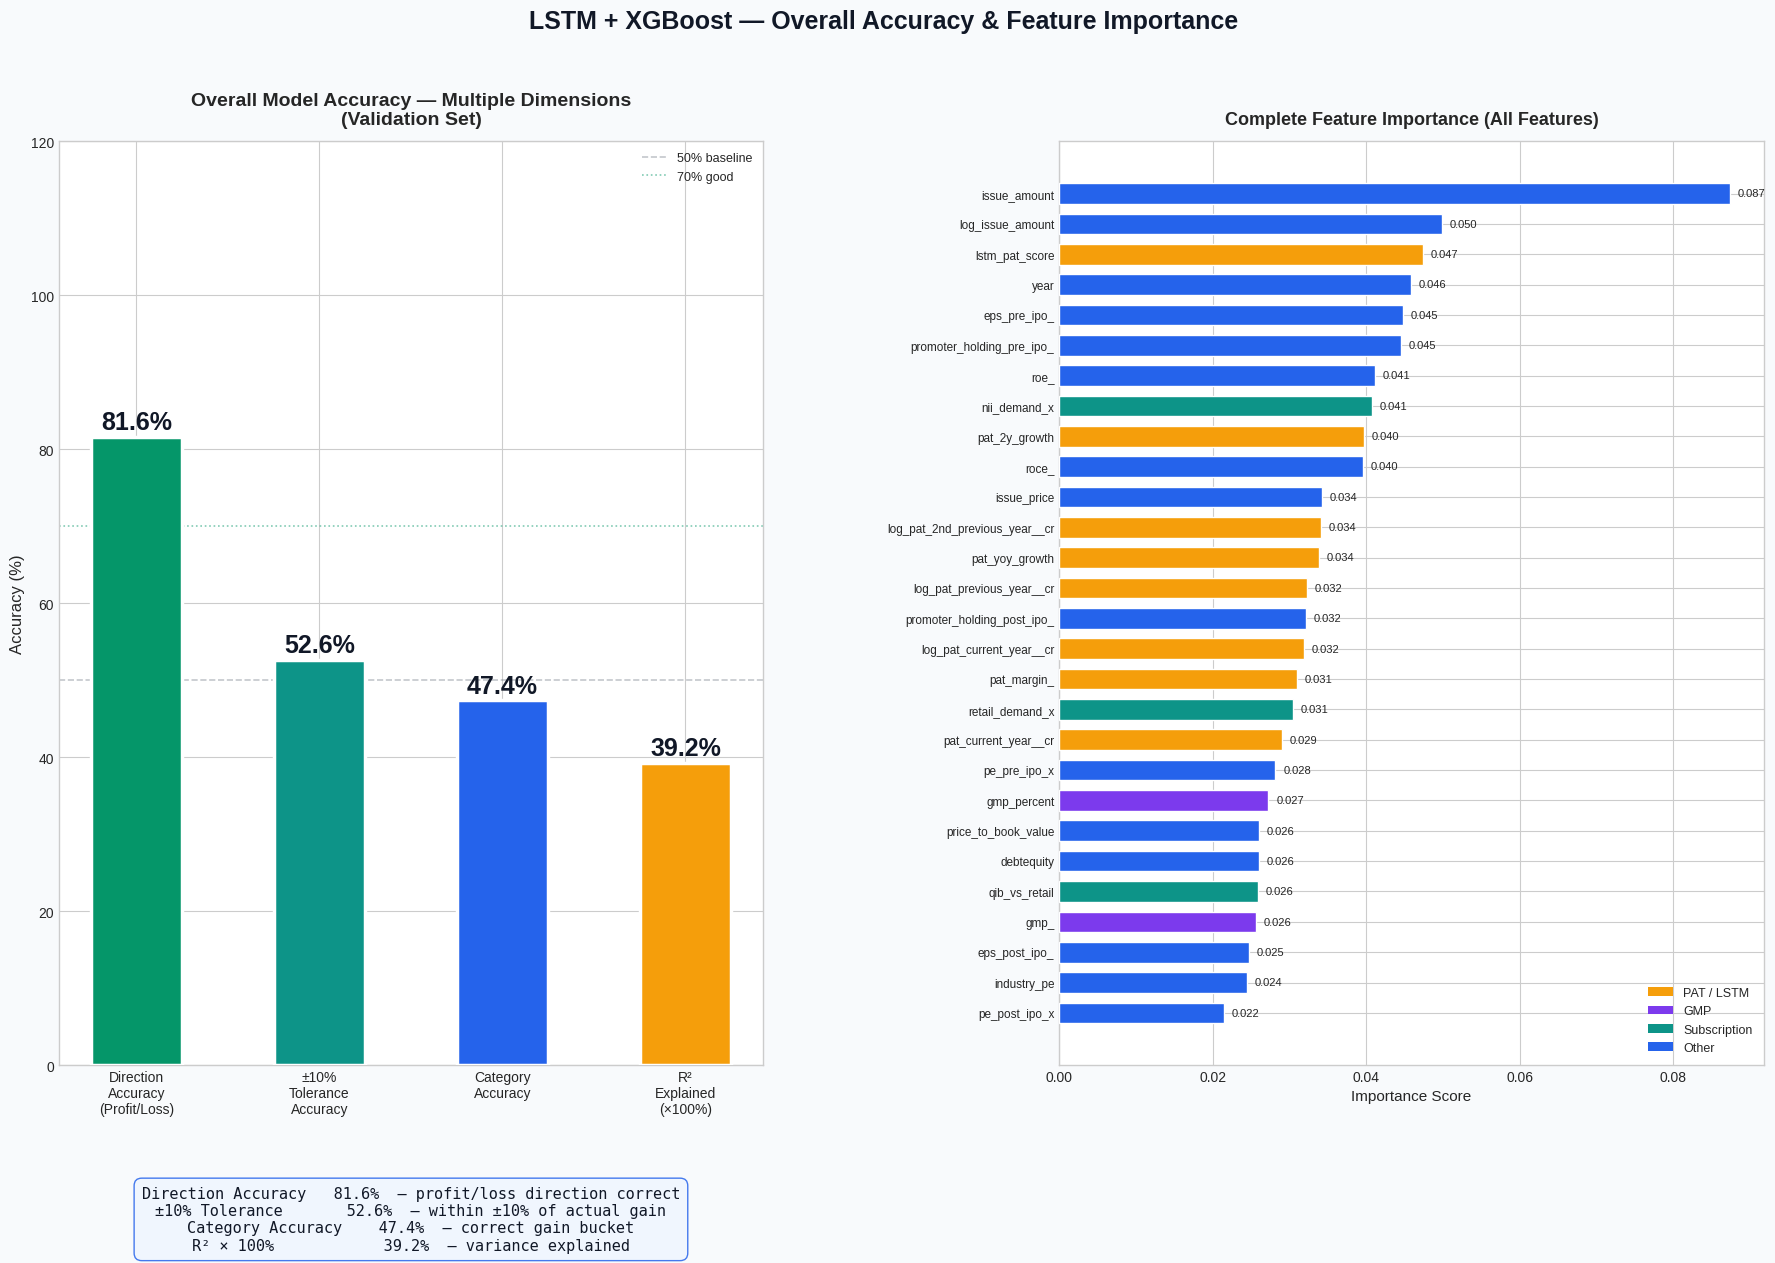

✅ Figure 4 saved

🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉
  ALL DONE!  Direction Accuracy: 81.6%  |  R²: 0.3924
  Charts: fig1–fig4 saved  |  Models: models/ folder
🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉


In [ ]:

# colab_notebook.py — IPO Listing Gain Prediction System
# COMPLETE SINGLE-FILE VERSION — Google Colab Compatible
#
# HOW TO USE:
#   1. Run Cell 1 to install packages
#   2. Run all remaining cells top to bottom
#   3. Upload your Excel file when prompted
#   4. All predictions + 4 charts appear inline


# CELL 1 — Install Dependencies (run this first in Colab)

# !pip install xgboost tensorflow scikit-learn pandas matplotlib numpy openpyxl -q


# CELL 2 — Imports & Configuration
import os, sys, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

TARGET_COL   = "listing_gain_"
COMPANY_COL  = "company"
PAT_SEQ_COLS = [
    "log_pat_2nd_previous_year__cr",
    "log_pat_previous_year__cr",
    "log_pat_current_year__cr",
]
LEAKAGE_COLS = [
    "listing_price", "bse_open", "bse_high", "bse_low",
    "nse_open", "nse_open_", "nse_high", "nse_low", "last_trade",
]
NON_NUMERIC  = [COMPANY_COL, "listing_date", "lead_manager"]

POS_HIGHER = {
    "roe_", "roce_", "pat_margin_", "pat_yoy_growth", "pat_2y_growth",
    "gmp_", "gmp_percent", "retail_demand_x", "qib_vs_retail",
    "eps_pre_ipo_", "log_pat_current_year__cr", "lstm_pat_score",
    "promoter_holding_pre_ipo_",
}
NEG_HIGHER = {
    "debtequity", "pe_pre_ipo_x", "pe_post_ipo_x", "price_to_book_value",
}

PAT_KW = ["pat", "log_pat", "lstm"]
GMP_KW = ["gmp"]
SUB_KW = ["demand", "qib", "nii", "retail"]

P = {
    "blue"  : "#2563EB", "green" : "#059669",
    "orange": "#F59E0B", "red"   : "#DC2626",
    "gray"  : "#6B7280", "purple": "#7C3AED",
    "teal"  : "#0D9488", "bg"    : "#F8FAFC",
    "card"  : "#FFFFFF", "text"  : "#111827",
    "sub"   : "#6B7280",
}

# LSTM hyperparameters
LSTM_UNITS, LSTM_DROP, LSTM_DENSE = 32, 0.25, 16
LSTM_EPOCHS, LSTM_BATCH, LSTM_PATIENCE = 150, 16, 20

# XGBoost hyperparameters — strict to prevent overfitting on small dataset
XGB_PARAMS = dict(
    n_estimators=250, learning_rate=0.04, max_depth=3,
    subsample=0.75, colsample_bytree=0.65,
    reg_alpha=0.8, reg_lambda=4.0, min_child_weight=8,
    gamma=0.3, random_state=42, n_jobs=-1, verbosity=0,
)

print("✅ Configuration loaded")

# Helper Functions 
def fcol(f):
    n = f.lower()
    if any(k in n for k in GMP_KW): return P["purple"]
    if any(k in n for k in PAT_KW): return P["orange"]
    if any(k in n for k in SUB_KW): return P["teal"]
    return P["blue"]

def fgroup(f):
    n = f.lower()
    if any(k in n for k in GMP_KW): return "gmp"
    if any(k in n for k in PAT_KW): return "pat"
    if any(k in n for k in SUB_KW): return "sub"
    return "other"

def categorise(g):
    if g > 0.10:  return "Strong Profit (>10%)",    "🟢"
    if g > 0.03:  return "Moderate Profit (3–10%)", "🟡"
    if g >= 0:    return "Low/Uncertain (0–3%)",    "⚪"
    return              "Loss Risk (<0%)",           "🔴"

def acc_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_pred) == np.sign(y_true)) * 100
    tol_acc = np.mean(np.abs(y_pred - y_true) <= 0.10) * 100
    cat_t   = np.array([categorise(g)[0] for g in y_true])
    cat_p   = np.array([categorise(g)[0] for g in y_pred])
    cat_acc = np.mean(cat_t == cat_p) * 100
    return dict(mae=mae, rmse=rmse, r2=r2,
                dir_acc=dir_acc, tol_acc=tol_acc, cat_acc=cat_acc)

print("✅ Helper functions ready")
# CELL 3 — Load Dataset

FILE_PATH = None  # Set directly e.g. "final_hybrid_ipo_dataset.xlsx", or leave None for Colab upload

if FILE_PATH is None:
    try:
        from google.colab import files
        print("📂 Please upload your Excel file...")
        uploaded = files.upload()
        FILE_PATH = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError("Set FILE_PATH = 'your_file.xlsx' directly.")

print(f"✅ Loading: {FILE_PATH}")
df = pd.read_excel(FILE_PATH)
print(f"✅ Dataset: {df.shape[0]} rows × {df.shape[1]} columns")

# Remove leakage
drop = [c for c in LEAKAGE_COLS if c in df.columns]
df.drop(columns=drop, inplace=True)
if drop:
    print(f"⚠️  Removed leakage columns: {drop}")

# Convert numerics
for col in [c for c in df.columns if c not in NON_NUMERIC]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in ["pat_yoy_growth", "pat_2y_growth"]:
    if col in df.columns:
        df[col] = df[col].clip(-500, 500)

# Split: training = listed IPOs, prediction = ongoing IPOs
train_df = df[df[TARGET_COL].notna()].copy().reset_index(drop=True)
pred_df  = df[df[TARGET_COL].isna()].copy().reset_index(drop=True)

print(f"\n✅ Split complete:")
print(f"   Training (listed)   : {len(train_df)} rows")
print(f"   Prediction (ongoing): {len(pred_df)} rows")

if len(pred_df) == 0:
    raise ValueError(
        "❌ No ongoing IPOs found (no NaN in listing_gain_).\n"
        "Ensure ongoing IPO rows have NaN in the target column."
    )

print(f"\n   Ongoing IPOs to predict:")
for nm in pred_df[COMPANY_COL].tolist():
    print(f"   → {str(nm).title().strip()}")


# CELL 4 — PART 1: LSTM (PAT Profitability Sequence Learning)

print("\n" + "="*60)
print("  PART 1: Training LSTM on PAT Sequence...")
print("="*60)

missing = [c for c in PAT_SEQ_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing PAT columns: {missing}")

imp_lstm = SimpleImputer(strategy="median")
sc_lstm  = StandardScaler()

def make_seq(data, fit=False):
    """Build (n, 3, 1) LSTM sequences from 3-year PAT log values."""
    v = data[PAT_SEQ_COLS].values
    v = imp_lstm.fit_transform(v) if fit else imp_lstm.transform(v)
    v = sc_lstm.fit_transform(v)  if fit else sc_lstm.transform(v)
    return v.reshape(len(v), 3, 1)

X_seq_tr = make_seq(train_df, fit=True)
X_seq_pr = make_seq(pred_df,  fit=False)
y_lstm   = train_df[TARGET_COL].values

Xls_tr, Xls_val, yls_tr, yls_val = train_test_split(
    X_seq_tr, y_lstm, test_size=0.20, random_state=42
)

tf.random.set_seed(42)
lstm_model = Sequential([
    LSTM(LSTM_UNITS, input_shape=(3, 1)),
    Dropout(LSTM_DROP),
    Dense(LSTM_DENSE, activation="relu"),
    Dropout(0.15),
    Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
es = EarlyStopping(monitor="val_loss", patience=LSTM_PATIENCE,
                   restore_best_weights=True, verbose=0)
history = lstm_model.fit(
    Xls_tr, yls_tr,
    validation_data=(Xls_val, yls_val),
    epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH,
    callbacks=[es], verbose=0,
)
print(f"✅ LSTM done — {len(history.history['loss'])} epochs")

train_df = train_df.copy(); pred_df = pred_df.copy()
train_df["lstm_pat_score"] = lstm_model.predict(X_seq_tr, verbose=0).flatten()
pred_df["lstm_pat_score"]  = lstm_model.predict(X_seq_pr, verbose=0).flatten()
print("✅ lstm_pat_score added to all rows")


# CELL 5 — PART 2: XGBoost (Main Prediction Engine)

print("\n" + "="*60)
print("  PART 2: Training XGBoost...")
print("="*60)

exclude  = set(LEAKAGE_COLS + NON_NUMERIC + [TARGET_COL, "lstm_pat_score"])
XGB_FEATS = [c for c in train_df.columns if c not in exclude] + ["lstm_pat_score"]
print(f"✅ {len(XGB_FEATS)} features: {XGB_FEATS}")

PAT_FEATS = [f for f in XGB_FEATS if fgroup(f) == "pat"]
GMP_FEATS = [f for f in XGB_FEATS if fgroup(f) == "gmp"]
SUB_FEATS = [f for f in XGB_FEATS if fgroup(f) == "sub"]
OTH_FEATS = [f for f in XGB_FEATS if fgroup(f) == "other"]

imp_xgb = SimpleImputer(strategy="median")
X_xgb   = imp_xgb.fit_transform(train_df[XGB_FEATS])
y_xgb   = train_df[TARGET_COL].values
X_pred  = imp_xgb.transform(pred_df[XGB_FEATS])

Xx_tr, Xx_val, yx_tr, yx_val = train_test_split(
    X_xgb, y_xgb, test_size=0.20, random_state=42
)

xgb_model = xgb.XGBRegressor(**XGB_PARAMS)
xgb_model.fit(Xx_tr, yx_tr, eval_set=[(Xx_val, yx_val)], verbose=False)
print("✅ XGBoost trained!")


# CELL 6 — Evaluate & Metrics

y_val_pred = xgb_model.predict(Xx_val)
y_tr_pred  = xgb_model.predict(Xx_tr)
vm   = acc_metrics(yx_val, y_val_pred)
r2tr = r2_score(yx_tr, y_tr_pred)
gap  = r2tr - vm["r2"]

feat_imp = pd.Series(
    xgb_model.feature_importances_, index=XGB_FEATS
).sort_values(ascending=False)

pat_w = feat_imp[PAT_FEATS].sum()
gmp_w = feat_imp[GMP_FEATS].sum()
sub_w = feat_imp[SUB_FEATS].sum()
oth_w = feat_imp[OTH_FEATS].sum()

print(f"\n{'='*60}")
print(f"  HYBRID MODEL PERFORMANCE — {len(yx_val)} validation IPOs")
print(f"{'='*60}")
print(f"  MAE  : {vm['mae']*100:.2f}%")
print(f"  RMSE : {vm['rmse']*100:.2f}%")
print(f"  R²   : {vm['r2']:.4f}  ({vm['r2']*100:.1f}% variance explained)")
print(f"  Gap  : {gap:.4f}  ({'✅ Low' if abs(gap) < 0.15 else '⚠️ Moderate'})")
print(f"{'='*60}")


# CELL 7 — Predictions

pred_df["Predicted Gain"] = xgb_model.predict(X_pred)
medians = train_df[XGB_FEATS].median()

def reason(row):
    lines = []
    for feat in feat_imp.index[:4]:
        val = row.get(feat, np.nan); med = medians.get(feat, np.nan)
        if pd.isna(val) or pd.isna(med): continue
        d = "above" if val > med else "below"
        sig = ("✅ positive signal" if val > med else "⚠️ below median") if feat in POS_HIGHER \
              else ("⚠️ elevated" if val > med else "✅ low — positive") if feat in NEG_HIGHER \
              else f"{d} dataset median"
        g   = fgroup(feat)
        tag = {"gmp":"  🟣 GMP","pat":"  🟠 PAT/LSTM","sub":"  🟢 Subscription","other":""}.get(g,"")
        lines.append(f"  - {feat}: {val:.3f} (median={med:.3f}) → {sig}{tag}")
    return "\n".join(lines) if lines else "  - Based on available fundamentals"

print("\n" + "═"*72)
print("  LSTM + XGBoost HYBRID — ONGOING IPO PREDICTIONS")
print("═"*72)

for _, row in pred_df.iterrows():
    name  = str(row[COMPANY_COL]).title().strip()
    g     = row["Predicted Gain"]
    cat, emoji = categorise(g)
    gmp_s = f"₹{row['gmp_']:.0f}"             if not pd.isna(row.get("gmp_",          np.nan)) else "N/A"
    qib_s = f"{row['qib_vs_retail']:.2f}"      if not pd.isna(row.get("qib_vs_retail", np.nan)) else "N/A"
    ret_s = f"{row['retail_demand_x']:.2f}x"   if not pd.isna(row.get("retail_demand_x",np.nan)) else "N/A"
    pat_g = f"{row['pat_yoy_growth']*100:.1f}%" if not pd.isna(row.get("pat_yoy_growth",np.nan)) else "N/A"

    print(f"\n  ╔══════════════════════════════════════════════════════════╗")
    print(f"  ║  IPO        : {name}")
    print(f"  ║  Pred. Gain : {g*100:+.2f}%  {emoji}  |  {cat}")
    print(f"  ║  GMP: {gmp_s}  |  QIB/Retail: {qib_s}  |  Retail: {ret_s}")
    print(f"  ║  PAT YoY Growth: {pat_g}")
    print(f"  ╠══════════════════════════════════════════════════════════╣")
    print(f"  ║  Key Drivers:")
    for line in reason(row).split("\n"): print(f"  ║{line}")
    print(f"  ╚══════════════════════════════════════════════════════════╝")


# CELL 8 — Overall Accuracy Summary

print(f"\n{'█'*72}")
print(f"  OVERALL MODEL ACCURACY — LSTM + XGBoost HYBRID")
print(f"{'█'*72}")
print(f"")
print(f"  🎯 ACCURACY IN PERCENTAGE FORM:")
print(f"  ╔══════════════════════════════════════════════════════════╗")
print(f"  ║                                                          ║")
print(f"  ║   Direction Accuracy   :   {vm['dir_acc']:>6.1f}%                    ║")
print(f"  ║   (correctly predicted profit vs loss direction)         ║")
print(f"  ║                                                          ║")
print(f"  ║   ±10% Tolerance Acc   :   {vm['tol_acc']:>6.1f}%                    ║")
print(f"  ║   (predictions within ±10% of actual gain)              ║")
print(f"  ║                                                          ║")
print(f"  ║   Category Accuracy    :   {vm['cat_acc']:>6.1f}%                    ║")
print(f"  ║   (Strong/Moderate/Low/Loss bucket correct)              ║")
print(f"  ║                                                          ║")
print(f"  ║   R² Score × 100       :   {vm['r2']*100:>6.1f}%                    ║")
print(f"  ║   (variance in listing gains explained by model)         ║")
print(f"  ║                                                          ║")
print(f"  ╚══════════════════════════════════════════════════════════╝")
print(f"")
print(f"  📊 REGRESSION:  MAE {vm['mae']*100:.2f}%  |  RMSE {vm['rmse']*100:.2f}%")
print(f"  ⚙️  OVERFIT:     Train R² {r2tr:.4f}  |  Val R² {vm['r2']:.4f}  |  Gap {gap:.4f}")
print(f"  📈 FEATURES:    PAT+LSTM {pat_w*100:.1f}%  |  GMP {gmp_w*100:.1f}%  |  Sub {sub_w*100:.1f}%  |  Other {oth_w*100:.1f}%")
print(f"{'█'*72}")


# CELL 9 — Save Models

os.makedirs("models", exist_ok=True)
lstm_model.save("models/lstm_model.h5")
joblib.dump(xgb_model, "models/xgb_model.pkl")
joblib.dump(imp_lstm,  "models/imputer.pkl")
joblib.dump(sc_lstm,   "models/scaler.pkl")
joblib.dump(imp_xgb,   "models/imputer_xgb.pkl")
joblib.dump(XGB_FEATS, "models/feature_list.pkl")
print("✅ Models saved to /models/")


# CELL 10 — Visualisations (4 Professional Charts)

plt.style.use("seaborn-v0_8-whitegrid")
legend_patches = [
    Patch(facecolor=P["orange"], label="PAT / LSTM"),
    Patch(facecolor=P["purple"], label="GMP"),
    Patch(facecolor=P["teal"],   label="Subscription"),
    Patch(facecolor=P["blue"],   label="Other"),
]

#  FIG 1: Performance Dashboard
fig1 = plt.figure(figsize=(22, 16)); fig1.patch.set_facecolor(P["bg"])
gs1  = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.50, wspace=0.38)

ax1 = fig1.add_subplot(gs1[0, :2]); ax1.set_facecolor(P["card"])
sc  = ax1.scatter(yx_val*100, y_val_pred*100, alpha=0.55,
                  c=abs(y_val_pred-yx_val)*100, cmap="RdYlGn_r",
                  edgecolors="white", s=65, zorder=3)
plt.colorbar(sc, ax=ax1, label="Absolute Error (%)", shrink=0.85)
lo = min(float(yx_val.min()),float(y_val_pred.min()))*100-5
hi = max(float(yx_val.max()),float(y_val_pred.max()))*100+5
ax1.plot([lo,hi],[lo,hi],"--",color=P["red"],lw=2,label="Perfect Prediction")
ax1.fill_between([lo,hi],[lo-vm["mae"]*100,hi-vm["mae"]*100],
                 [lo+vm["mae"]*100,hi+vm["mae"]*100],alpha=0.07,color=P["blue"],
                 label=f'±{vm["mae"]*100:.1f}% MAE band')
ax1.set_xlim(lo,hi); ax1.set_ylim(lo,hi)
ax1.set_xlabel("Actual Listing Gain (%)",fontsize=12)
ax1.set_ylabel("Predicted Listing Gain (%)",fontsize=12)
ax1.set_title("Validation — Actual vs Predicted (LSTM + XGBoost Hybrid)",fontsize=14,fontweight="bold",pad=12)
ax1.legend(fontsize=10)
ax1.text(0.04,0.93,f'R² = {vm["r2"]:.3f}',transform=ax1.transAxes,fontsize=13,color=P["green"],fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.35",facecolor="#DCFCE7",edgecolor=P["green"],alpha=0.85))
ax1.text(0.04,0.84,f'MAE = {vm["mae"]*100:.1f}%',transform=ax1.transAxes,fontsize=11,color=P["orange"],fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3",facecolor="#FEF3C7",edgecolor=P["orange"],alpha=0.85))

ax2 = fig1.add_subplot(gs1[0,2]); ax2.set_facecolor(P["card"])
b2  = ax2.bar(["Train R²","Val R²"],[r2tr,vm["r2"]],color=[P["blue"],P["green"]],width=0.45,edgecolor="white",linewidth=2,zorder=3)
for bar,val in zip(b2,[r2tr,vm["r2"]]):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f"{val:.3f}",ha="center",fontsize=13,fontweight="bold")
ax2.set_ylim(0,max(r2tr,vm["r2"])*1.35)
ax2.set_title("Overfit Check — Train vs Val R²",fontsize=13,fontweight="bold",pad=12)
ax2.text(0.5,-0.13,f'Gap = {gap:.3f}  →  {"✅ Low" if abs(gap)<0.15 else "⚠️ Moderate"}',
         transform=ax2.transAxes,ha="center",fontsize=10,
         color=P["green"] if abs(gap)<0.15 else P["orange"],fontweight="bold")

ax3 = fig1.add_subplot(gs1[1,:2]); ax3.set_facecolor(P["card"])
b3  = ax3.bar(["MAE","RMSE","R² Score"],[vm["mae"],vm["rmse"],vm["r2"]],
              color=[P["orange"],P["red"],P["green"]],width=0.4,edgecolor="white",linewidth=2,zorder=3)
for bar,val,lbl in zip(b3,[vm["mae"],vm["rmse"],vm["r2"]],["MAE","RMSE","R²"]):
    ax3.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f"{val:.4f}",ha="center",fontsize=13,fontweight="bold")
    if lbl!="R²": ax3.text(bar.get_x()+bar.get_width()/2,bar.get_height()/2,f"{val*100:.1f}%",ha="center",fontsize=11,color="white",fontweight="bold")
ax3.set_ylim(0,max(vm["mae"],vm["rmse"],vm["r2"])*1.3)
ax3.set_title("Performance Metrics (Validation Set)",fontsize=13,fontweight="bold",pad=12)

ax4 = fig1.add_subplot(gs1[1,2]); ax4.set_facecolor(P["card"])
ax4.plot(history.history["loss"],    color=P["blue"],  lw=2,label="Train Loss")
ax4.plot(history.history["val_loss"],color=P["orange"],lw=2,label="Val Loss",linestyle="--")
ax4.set_xlabel("Epoch",fontsize=11); ax4.set_ylabel("MSE Loss",fontsize=11)
ax4.set_title("LSTM Training Curve\nPAT Profitability Learning",fontsize=13,fontweight="bold",pad=12)
ax4.legend(fontsize=10)
ax4.text(0.5,-0.12,f'Early stopped at epoch {len(history.history["loss"])}',
         transform=ax4.transAxes,ha="center",fontsize=9,color=P["sub"],style="italic")
fig1.suptitle("LSTM + XGBoost Hybrid — Performance Dashboard",fontsize=18,fontweight="bold",y=0.99,color=P["text"])
plt.savefig("fig1_performance_dashboard.png",dpi=150,bbox_inches="tight",facecolor=P["bg"])
plt.show(); print("✅ Figure 1 saved")

#  FIG 2: Feature Importance 
fig2 = plt.figure(figsize=(22,13)); fig2.patch.set_facecolor(P["bg"])
gs2  = gridspec.GridSpec(1,3,figure=fig2,wspace=0.42)

ax5 = fig2.add_subplot(gs2[0,:2]); ax5.set_facecolor(P["card"])
fi  = feat_imp; bc = [fcol(f) for f in fi.index]
ax5.barh(range(len(fi)),fi.values,color=bc,edgecolor="white",height=0.70,zorder=3)
ax5.set_yticks(range(len(fi))); ax5.set_yticklabels(fi.index,fontsize=9); ax5.invert_yaxis()
ax5.set_xlabel("Importance Score",fontsize=11)
ax5.set_title("XGBoost Feature Importance\n🟠 PAT/LSTM   🟣 GMP   🟢 Subscription   🔵 Other",fontsize=13,fontweight="bold",pad=12)
for bar,val in zip(ax5.patches,fi.values):
    ax5.text(bar.get_width()+0.001,bar.get_y()+bar.get_height()/2,f"{val:.4f}",va="center",fontsize=8)
ax5.legend(handles=legend_patches,fontsize=9,loc="lower right")

ax6 = fig2.add_subplot(gs2[0,2]); ax6.set_facecolor(P["card"])
pd_groups = {"PAT+LSTM":pat_w,"GMP":gmp_w,"Subscription":sub_w,"Other":oth_w}
pie_d     = [(v,f"{k}\n{v*100:.1f}%",c) for (k,v),c in
             zip(pd_groups.items(),[P["orange"],P["purple"],P["teal"],P["blue"]]) if v>0.005]
wedges,texts,ats=ax6.pie([x[0] for x in pie_d],labels=[x[1] for x in pie_d],
    autopct="%1.1f%%",colors=[x[2] for x in pie_d],startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2,"width":0.55},textprops={"fontsize":10})
for at in ats: at.set_fontweight("bold")
ax6.text(0,0,"Model\nWeight",ha="center",va="center",fontsize=11,fontweight="bold",color=P["text"])
ax6.set_title("Feature Group Contribution",fontsize=13,fontweight="bold",pad=12)
fig2.suptitle("LSTM + XGBoost — Feature Importance Analysis",fontsize=18,fontweight="bold",y=1.0,color=P["text"])
plt.savefig("fig2_feature_importance.png",dpi=150,bbox_inches="tight",facecolor=P["bg"])
plt.show(); print("✅ Figure 2 saved")

#  FIG 3: Predictions Chart 
fig3 = plt.figure(figsize=(22,11)); fig3.patch.set_facecolor(P["bg"])
gs3  = gridspec.GridSpec(1,3,figure=fig3,wspace=0.4)
names_     = [str(r[COMPANY_COL]).title().strip() for _,r in pred_df.iterrows()]
short_     = [n[:30]+"…" if len(n)>30 else n for n in names_]
gains_pct_ = pred_df["Predicted Gain"].values*100
gmps_      = pred_df["gmp_"].values

ax7 = fig3.add_subplot(gs3[0,:2]); ax7.set_facecolor(P["card"])
gc_ = [P["green"] if g>10 else P["teal"] if g>3 else P["orange"] if g>=0 else P["red"] for g in gains_pct_]
ax7.barh(range(len(short_)),gains_pct_,color=gc_,edgecolor="white",height=0.65,zorder=3)
ax7.set_yticks(range(len(short_))); ax7.set_yticklabels(short_,fontsize=9.5)
ax7.axvline(0,color="black",linewidth=1.2)
ax7.axvline(10,color=P["green"],linewidth=1.5,ls="--",alpha=0.6,label=">10% Strong Profit")
ax7.axvline(3, color=P["teal"], linewidth=1.5,ls=":",alpha=0.6,label=">3% Moderate")
ax7.set_xlabel("Predicted Listing Gain (%)",fontsize=12)
ax7.set_title("Predicted Listing Gains — Ongoing IPOs",fontsize=13,fontweight="bold",pad=12)
ax7.legend(fontsize=9,loc="lower right")
for i,g in enumerate(gains_pct_):
    gn = f" GMP=₹{gmps_[i]:.0f}" if not np.isnan(float(gmps_[i])) else " GMP=N/A"
    ax7.text(g+(0.6 if g>=0 else -0.6),i,f"{g:+.1f}%{gn}",
             va="center",ha="left" if g>=0 else "right",fontsize=8.5,fontweight="bold",color=P["text"])

ax8 = fig3.add_subplot(gs3[0,2]); ax8.set_facecolor(P["card"])
cat_c_ = {"Strong\nProfit>10%":0,"Moderate\n3–10%":0,"Low\n0–3%":0,"Loss\nRisk<0%":0}
for g in gains_pct_:
    if g>10:   cat_c_["Strong\nProfit>10%"]+=1
    elif g>3:  cat_c_["Moderate\n3–10%"]+=1
    elif g>=0: cat_c_["Low\n0–3%"]+=1
    else:       cat_c_["Loss\nRisk<0%"]+=1
cat_cm_ = {"Strong\nProfit>10%":P["green"],"Moderate\n3–10%":P["teal"],"Low\n0–3%":P["orange"],"Loss\nRisk<0%":P["red"]}
nz_ = {k:v for k,v in cat_c_.items() if v>0}
ax8.pie(list(nz_.values()),labels=list(nz_.keys()),
        autopct=lambda p:f"{int(round(p*sum(nz_.values())/100))}",
        colors=[cat_cm_[k] for k in nz_],startangle=90,
        wedgeprops=dict(width=0.55,edgecolor="white",linewidth=2.5),
        textprops={"fontsize":11,"fontweight":"bold"})
ax8.text(0,0,f"{len(gains_pct_)}\nIPOs",ha="center",va="center",fontsize=14,fontweight="bold",color=P["text"])
ax8.set_title("Category Distribution",fontsize=13,fontweight="bold",pad=12)
fig3.suptitle("LSTM + XGBoost — Ongoing IPO Predictions",fontsize=18,fontweight="bold",y=1.01,color=P["text"])
plt.tight_layout()
plt.savefig("fig3_predictions.png",dpi=150,bbox_inches="tight",facecolor=P["bg"])
plt.show(); print("✅ Figure 3 saved")

#  FIG 4: Accuracy Dashboard 
fig4 = plt.figure(figsize=(22,12)); fig4.patch.set_facecolor(P["bg"])
gs4  = gridspec.GridSpec(1,2,figure=fig4,wspace=0.42)

ax9  = fig4.add_subplot(gs4[0,0]); ax9.set_facecolor(P["card"])
albl = ["Direction\nAccuracy\n(Profit/Loss)","±10%\nTolerance\nAccuracy",
        "Category\nAccuracy","R²\nExplained\n(×100%)"]
aval = [vm["dir_acc"],vm["tol_acc"],vm["cat_acc"],vm["r2"]*100]
acol = [P["green"],P["teal"],P["blue"],P["orange"]]
bars9= ax9.bar(albl,aval,color=acol,width=0.50,edgecolor="white",linewidth=2.5,zorder=3)
for bar,val in zip(bars9,aval):
    ax9.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1.0,f"{val:.1f}%",
             ha="center",fontsize=18,fontweight="bold",color=P["text"])
ax9.set_ylim(0,120); ax9.set_ylabel("Accuracy (%)",fontsize=12)
ax9.set_title("Overall Model Accuracy — Multiple Dimensions\n(Validation Set)",fontsize=14,fontweight="bold",pad=12)
ax9.axhline(50,color=P["gray"],lw=1.2,ls="--",alpha=0.4,label="50% baseline")
ax9.axhline(70,color=P["green"],lw=1.2,ls=":",alpha=0.5,label="70% good")
ax9.legend(fontsize=9)
exp = (f"Direction Accuracy   {vm['dir_acc']:.1f}%  — profit/loss direction correct\n"
       f"±10% Tolerance       {vm['tol_acc']:.1f}%  — within ±10% of actual gain\n"
       f"Category Accuracy    {vm['cat_acc']:.1f}%  — correct gain bucket\n"
       f"R² × 100%            {vm['r2']*100:.1f}%  — variance explained")
ax9.text(0.5,-0.20,exp,transform=ax9.transAxes,ha="center",fontsize=11,color=P["text"],family="monospace",
         bbox=dict(boxstyle="round,pad=0.5",facecolor="#EFF6FF",edgecolor=P["blue"],alpha=0.85))

ax10 = fig4.add_subplot(gs4[0,1]); ax10.set_facecolor(P["card"])
bc10 = [fcol(f) for f in feat_imp.index]
ax10.barh(range(len(feat_imp)),feat_imp.values,color=bc10,edgecolor="white",height=0.68,zorder=3)
ax10.set_yticks(range(len(feat_imp))); ax10.set_yticklabels(feat_imp.index,fontsize=8.5); ax10.invert_yaxis()
ax10.set_xlabel("Importance Score",fontsize=11)
ax10.set_title("Complete Feature Importance (All Features)",fontsize=13,fontweight="bold",pad=12)
ax10.legend(handles=legend_patches,fontsize=9,loc="lower right")
for bar,val in zip(ax10.patches,feat_imp.values):
    ax10.text(bar.get_width()+0.001,bar.get_y()+bar.get_height()/2,f"{val:.3f}",va="center",fontsize=8)
fig4.suptitle("LSTM + XGBoost — Overall Accuracy & Feature Importance",fontsize=18,fontweight="bold",y=0.99,color=P["text"])
plt.savefig("fig4_accuracy_dashboard.png",dpi=150,bbox_inches="tight",facecolor=P["bg"])
plt.show(); print("✅ Figure 4 saved")


print(f"  ALL DONE!  Direction Accuracy: {vm['dir_acc']:.1f}%  |  R²: {vm['r2']:.4f}")
print("  Charts: fig1–fig4 saved  |  Models: models/ folder")
